# Test 6-layered Deep CNN Model on Test Set

### Importing Libraries and Modules


In [1]:
# Deeplearning Libraries
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# import data handling libraries
import pandas as pd
import numpy as np

# import roc-auc from sklearn
from sklearn.metrics import roc_curve, auc, roc_auc_score

# import visualization libaries
import matplotlib.pyplot as plt
import seaborn as sns

# import custom modules for test, architecture, and graph generations
from modules.helper.tester import test
from modules.helper.calculate_metrics import calculate_metrics
from modules.helper.confusion_matrix_gen import plot_confusion_matrix
from modules.architectures.Architecture import Architecture

### Load Test Sets
Use datasets, transforms and DataLoader to create a test set with image size 112x112 and batch size 32.

In [2]:
torch.manual_seed(41)


transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])

test_data_set = datasets.ImageFolder("./datasets/final_dataset/test", transform=transform)

test_loader = DataLoader(
    test_data_set,
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
)

print("TEST SET CREATED!")

TEST SET CREATED!


### Create Model using Architecture and Custom Module Generator

In [3]:
# create model Architecture
model = Architecture()

def add_conv_layers(model, layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = 112
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool==0:
            model.add(nn.MaxPool2d(2,2))
            size = size//2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

params, channels, size = add_conv_layers(model, 6, 1)

print(f"Total Convolutional Parameters: {params}")
print(f"Final Convolutional Out Channels: {channels}")
print(f"Final Convolutional Size: {size}")

flatten_size = channels * size * size

l1_param = flatten_size * channels + channels

l2_param = channels * 36 + 36

total_params = params + l1_param + l2_param

model.add(
    nn.Flatten(),
    nn.Linear(flatten_size, channels),
    nn.ReLU(),
    nn.Linear(channels, 36)
)

print(f"TOTAL TRAINABLE PARAMETERS = {total_params}")

Total Convolutional Parameters: 394560
Final Convolutional Out Channels: 256
Final Convolutional Size: 14
TOTAL TRAINABLE PARAMETERS = 13249124


### Test exact model epoch 29

In [4]:
model_path = "./documentations/experiments/tika-6cnn-aug/models/epoch_29.pt"

metric, test_preds, test_targets = test(model, model_path, test_loader, nn.CrossEntropyLoss(), "cuda")

In [5]:
# Show metrics:
print("Metrics on Test Set:")
metric

Metrics on Test Set:


{'test_accuracy': 0.9993827160493827,
 'test_precision': 0.9993886818816953,
 'test_recall': 0.9993827160493827,
 'test_f1_score': 0.9993818642301553,
 'test_loss': 0.0019583692821631463}

### Plot Confusion Matrix

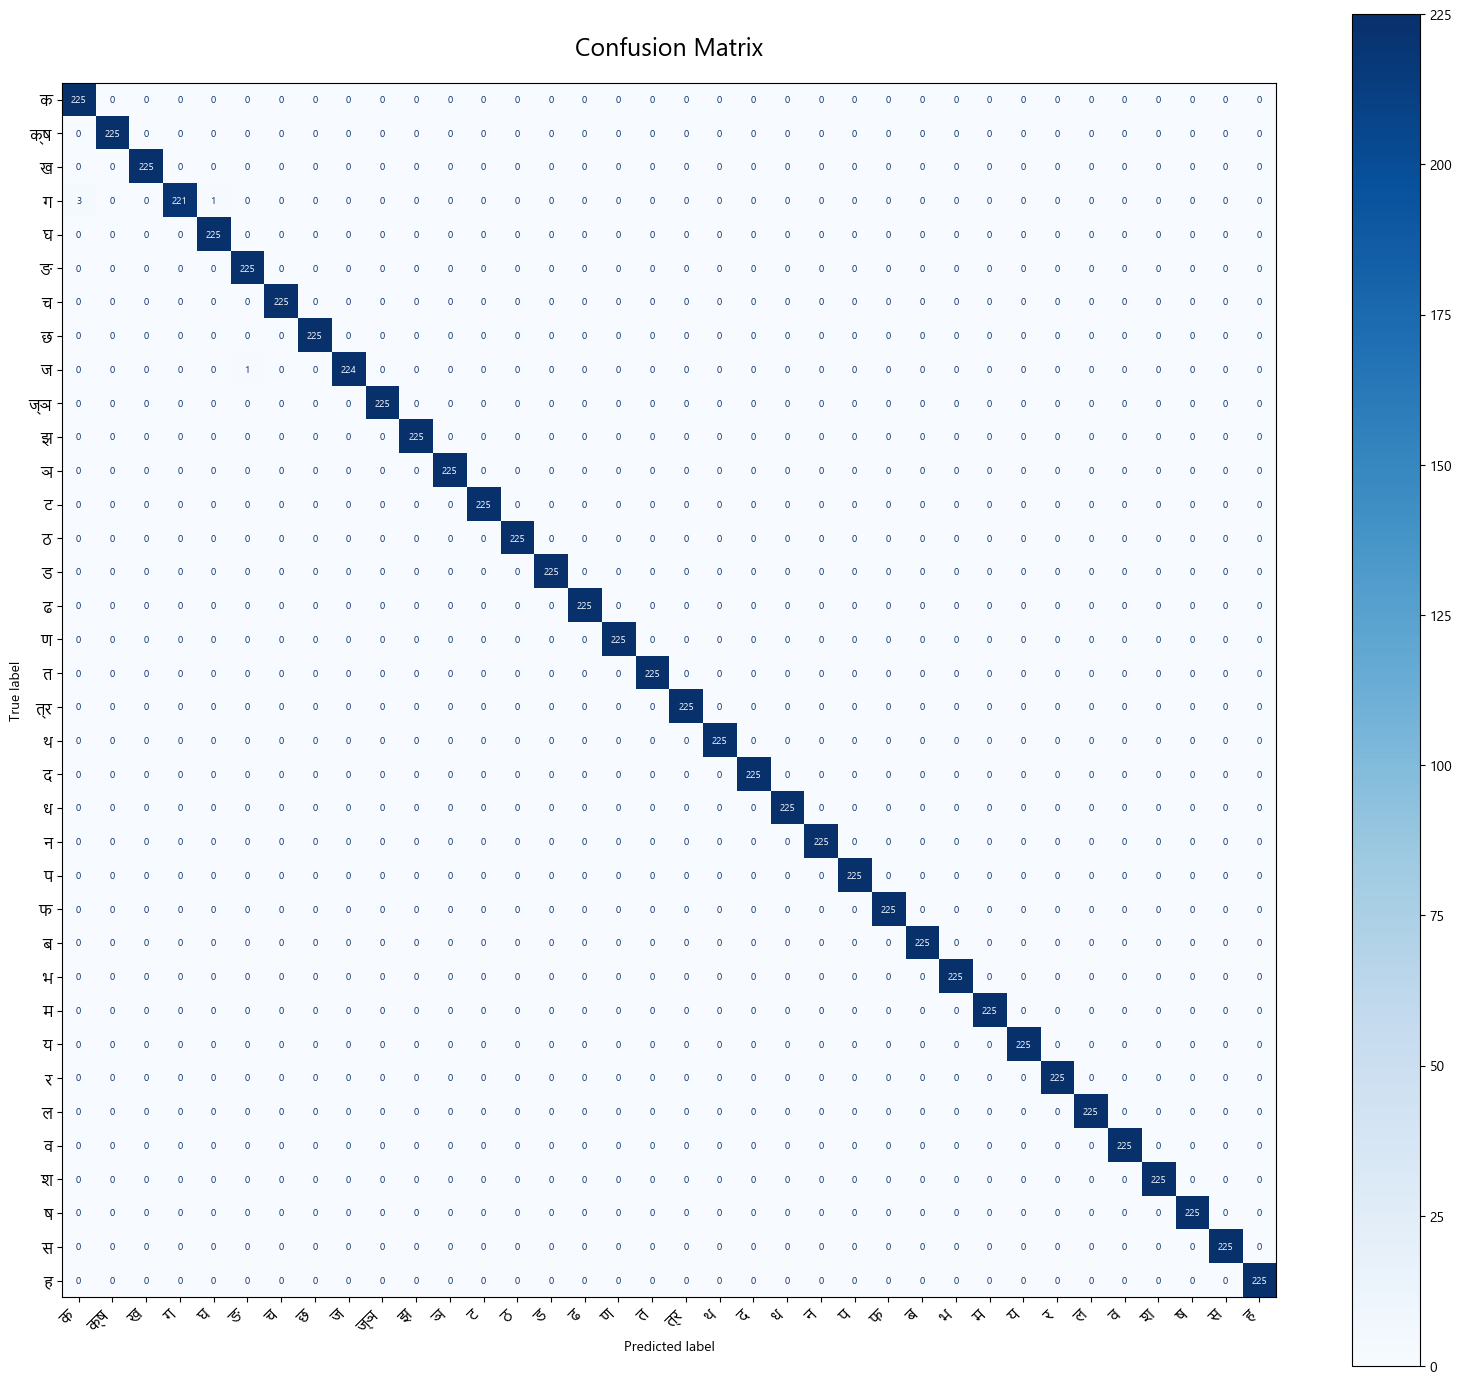

In [6]:
cm = plot_confusion_matrix(
    y_pred=test_preds.cpu().numpy(),
    y_true=test_targets.cpu().numpy(),
    save_path="./documentations/test-results/confusion-matrix-6cnn.png",
    class_names=test_loader.dataset.classes
)

In [7]:
cm

array([[225,   0,   0, ...,   0,   0,   0],
       [  0, 225,   0, ...,   0,   0,   0],
       [  0,   0, 225, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 225,   0,   0],
       [  0,   0,   0, ...,   0, 225,   0],
       [  0,   0,   0, ...,   0,   0, 225]], shape=(36, 36))

In [8]:
confusion_matrix = pd.DataFrame(cm)
confusion_matrix.to_csv("./documentations/test-results/confusion-matrix-6cnn.csv", index=False)

In [7]:
test_loader.dataset.classes

['क',
 'क्ष',
 'ख',
 'ग',
 'घ',
 'ङ',
 'च',
 'छ',
 'ज',
 'ज्ञ',
 'झ',
 'ञ',
 'ट',
 'ठ',
 'ड',
 'ढ',
 'ण',
 'त',
 'त्र',
 'थ',
 'द',
 'ध',
 'न',
 'प',
 'फ',
 'ब',
 'भ',
 'म',
 'य',
 'र',
 'ल',
 'व',
 'श',
 'ष',
 'स',
 'ह']